# Analiza kriminalitetnih podatkov v Sloveniji

**Podatki:** Policija RS — kazniva dejanja in osebe udeležene v KD  
**Struktura:**

1. Nalaganje in čiščenje podatkov
2. Opisna statistika
3. Porazdelitve (čas, lokacija, sredstva, državljanstvo, žrtev/osumljenec …)
4. Detekcija osamelcev
5. Gručenje (K-Means, aglomerativno)


## 1 Nalaganje podatkov


In [51]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage

plt.style.use("dark_background")
sns.set_palette("Set2")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "figure.dpi": 120,
    }
)
warnings.filterwarnings("ignore", category=FutureWarning)

In [52]:
from analysis.data_formatter import format_data_all
from analysis.population import get_population

YEAR = 2024

files: dict[int, Path] = {int(file.name[2:6]): file for file in format_data_all(force=True)}

df = pd.read_csv(files[YEAR], quoting=1, encoding="cp1250")
pop = get_population(YEAR, 1)

print(f"Podatki za leto {YEAR}")
print(f"  Število vrstic:   {len(df):,}")
print(f"  Število stolpcev: {df.shape[1]}")
print(f"  Populacija reg.:  {len(pop)} regij")

Podatki za leto 2024
  Število vrstic:   110,452
  Število stolpcev: 33
  Populacija reg.:  8 regij


## 2 Čiščenje in pregled podatkov


In [53]:
df.head()

,ZaporednaStevilkaKD,MesecStoritve,UraStoritve,DanVTednu,PUStoritveKD,Povratnik,OpisKD,PoglavjeKD,GospodarskiKriminal,OrganiziranKriminal,...,ZaporednaStevilkaOsebeVKD,VrstaOsebe,StarostniRazred,Spol,Drzavljanstvo,Poskodba,VplivAlkohola,VplivMamil,OrganiziranaZdruzba,Skoda
0,1,5.2014,00:00-00:59,PETEK,PU LJUBLJANA,NE,"KZ12/288*/1/G/ - PROTIZAKONITO, PRISTRANSKO IN...",KD ZOPER PRAVOSODJE,GOSPODARSKA,,...,1001.0,ŽRTEV,44-54,MOŠKI,SLOVENSKO,BREZ POŠKODBE,NN,NN,NE,0
1,1,5.2014,00:00-00:59,PETEK,PU LJUBLJANA,NE,"KZ12/288*/1/G/ - PROTIZAKONITO, PRISTRANSKO IN...",KD ZOPER PRAVOSODJE,GOSPODARSKA,,...,1002.0,ŽRTEV,54-64,MOŠKI,SLOVENSKO,BREZ POŠKODBE,NN,NN,NE,0
2,2,7.2014,20:00-20:59,NEDELJA,PU MURSKA SOBOTA,NE,KZ12/122*/1// - LAHKA TELESNA POŠKODBA,KD ZOPER ŽIVLJENJE IN TELO,SPLOŠNA,,...,2001.0,ŽRTEV,24-34,MOŠKI,SLOVENSKO,LAHKA TELESNA POŠKODBA,NN,NN,NE,0
3,3,5.2013,09:00-09:59,ČETRTEK,PU LJUBLJANA,NE,KZ12/179*/1// - MALOMARNO ZDRAVLJENJE IN OPRAV...,KD ZOPER ČLOVEKOVO ZDRAVJE,SPLOŠNA,,...,3001.0,ŽRTEV,00-07,MOŠKI,SLOVENSKO,POSEBNO HUDA TEL.POŠKODBA,NN,NN,NE,0
4,3,5.2013,09:00-09:59,ČETRTEK,PU LJUBLJANA,NE,KZ12/179*/1// - MALOMARNO ZDRAVLJENJE IN OPRAV...,KD ZOPER ČLOVEKOVO ZDRAVJE,SPLOŠNA,,...,3002.0,NaN,34-44,MOŠKI,SLOVENSKO,NaN,NN,NN,NE,0


In [54]:
df.dtypes

ZaporednaStevilkaKD             int64
MesecStoritve                 float64
UraStoritve                       str
DanVTednu                         str
PUStoritveKD                      str
Povratnik                         str
OpisKD                            str
PoglavjeKD                        str
GospodarskiKriminal               str
OrganiziranKriminal               str
MladoletniskaKriminaliteta        str
Poskus                            str
KriminalisticnaOznacba1           str
KriminalisticnaOznacba2           str
KriminalisticnaOznacba3           str
UporabljenoSredstvo1              str
UporabljenoSredstvo2              str
UporabljenoSredstvo3              str
UporabljenoSredstvo4              str
UpravnaEnotaStoritve              str
OpisKraja                         str
LetoZakljucnegaDokumenta        int64
VrstaZakljucnegaDokumenta         str
ZaporednaStevilkaOsebeVKD     float64
VrstaOsebe                        str
StarostniRazred                   str
Spol        

In [55]:
# manjkajoče vrednosti (%)
missing = df.isnull().mean().mul(100).round(1)
missing[missing > 0].sort_values(ascending=False)

UporabljenoSredstvo4         98.8
UporabljenoSredstvo3         96.8
KriminalisticnaOznacba3      94.3
UporabljenoSredstvo2         89.8
KriminalisticnaOznacba2      70.5
Poskodba                     61.5
UporabljenoSredstvo1         25.3
OpisKraja                    14.5
VrstaOsebe                    8.5
KriminalisticnaOznacba1       7.6
ZaporednaStevilkaOsebeVKD     0.4
StarostniRazred               0.4
Spol                          0.4
Drzavljanstvo                 0.4
VplivAlkohola                 0.4
VplivMamil                    0.4
OrganiziranaZdruzba           0.4
Skoda                         0.4
dtype: float64

In [56]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ZaporednaStevilkaKD,110452.0,3.219863e+04,1.903147e+04,1.0000,1.571175e+04,3.209750e+04,4.875600e+04,6.529700e+04
MesecStoritve,110452.0,6.678099e+00,3.409152e+00,1.1997,4.202200e+00,6.202400e+00,9.202400e+00,1.220240e+01
LetoZakljucnegaDokumenta,110452.0,2.024000e+03,0.000000e+00,2024.0000,2.024000e+03,2.024000e+03,2.024000e+03,2.024000e+03
ZaporednaStevilkaOsebeVKD,109986.0,3.222364e+07,1.902406e+07,1001.0000,1.573825e+07,3.213600e+07,4.876500e+07,6.529700e+07


In [57]:
# pretvori škodo v numerično
if "Skoda" in df.columns:
    df["Skoda_num"] = pd.to_numeric(df["Skoda"].astype(str).str.replace(",", "."), errors="coerce")

# vrednosti, ki jih obravnavamo kot manjkajoče
_NO_DATA = {"NI PODATKA", "NI  PODATKA", "NI PODATKOV", ""}

# za string stolpce zamenjaj "NI PODATKA" z NaN
for col in df.select_dtypes(include="object").columns:
    mask = df[col].str.strip().str.upper().isin(_NO_DATA) | df[col].isna()
    df.loc[mask, col] = np.nan

# lokacijski stolpci — odstrani tudi "GPU"
for loc_col in ["PUStoritveKD", "UpravnaEnotaStoritve"]:
    if loc_col in df.columns:
        df.loc[df[loc_col].str.strip().str.upper() == "GPU", loc_col] = np.nan

print("Čiščenje opravljeno.")
print(f"  NaN po čiščenju: {df.isna().sum().sum():,}")

/tmp/ipykernel_795095/1287552479.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


Čiščenje opravljeno.
  NaN po čiščenju: 896,402


## 3 Porazdelitve


In [58]:
def bar_plot(series, title, top_n=None, horizontal=False, ax=None):
    """Pomožna funkcija za frekvenčne stolpčne grafe."""
    counts = series.value_counts()
    if top_n:
        counts = counts.head(top_n)
    if ax is None:
        fig, ax = plt.subplots()
    if horizontal:
        counts.sort_values().plot.barh(ax=ax)
    else:
        counts.plot.bar(ax=ax)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()

### 3.1 Časovna porazdelitev


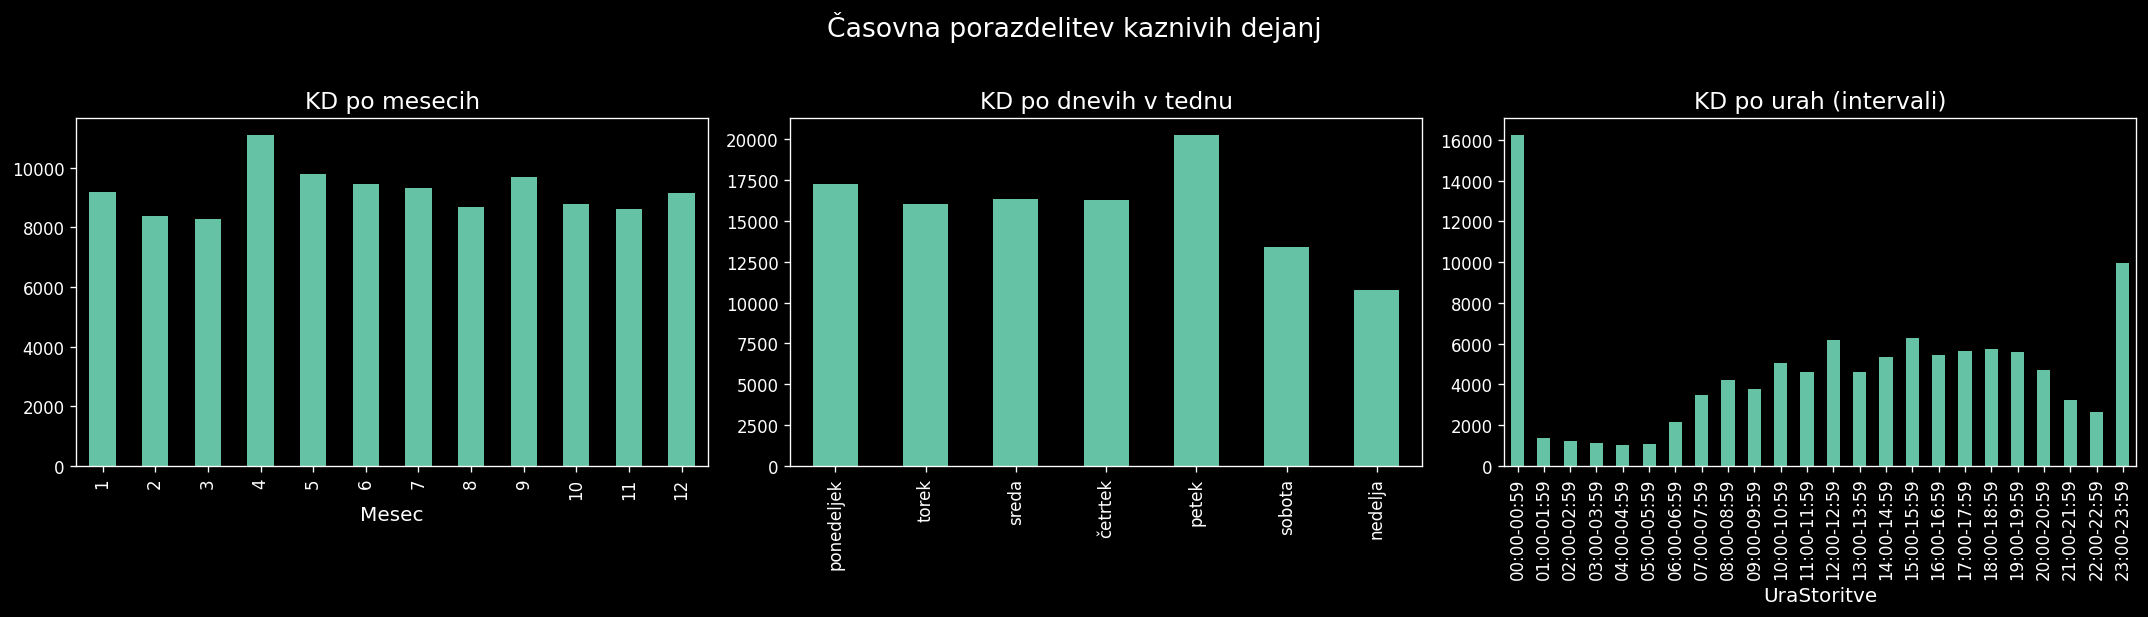

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# meseci — urejeno 1–12
meseci = df["MesecStoritve"].dropna().astype(int)
meseci_counts = meseci.value_counts().sort_index()
meseci_counts.plot.bar(ax=axes[0])
axes[0].set_title("KD po mesecih")
axes[0].set_xlabel("Mesec")

# dnevi — urejeno po tednu
dan_order = ["ponedeljek", "torek", "sreda", "četrtek", "petek", "sobota", "nedelja"]
dnevi = df["DanVTednu"].dropna().str.strip().str.lower()
dnevi_cat = pd.Categorical(dnevi, categories=dan_order, ordered=True)
dnevi_counts = pd.Series(dnevi_cat).value_counts().sort_index()
dnevi_counts.plot.bar(ax=axes[1])
axes[1].set_title("KD po dnevih v tednu")

hour_order = [f"{h:02d}:00-{h:02d}:59" for h in range(24)]
ure_counts = df["UraStoritve"].dropna().str.strip().value_counts().reindex(hour_order, fill_value=0)
ure_counts.plot.bar(ax=axes[2])
axes[2].set_title("KD po urah (intervali)")

fig.suptitle("Časovna porazdelitev kaznivih dejanj", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


### 3.2 Lokacijska porazdelitev


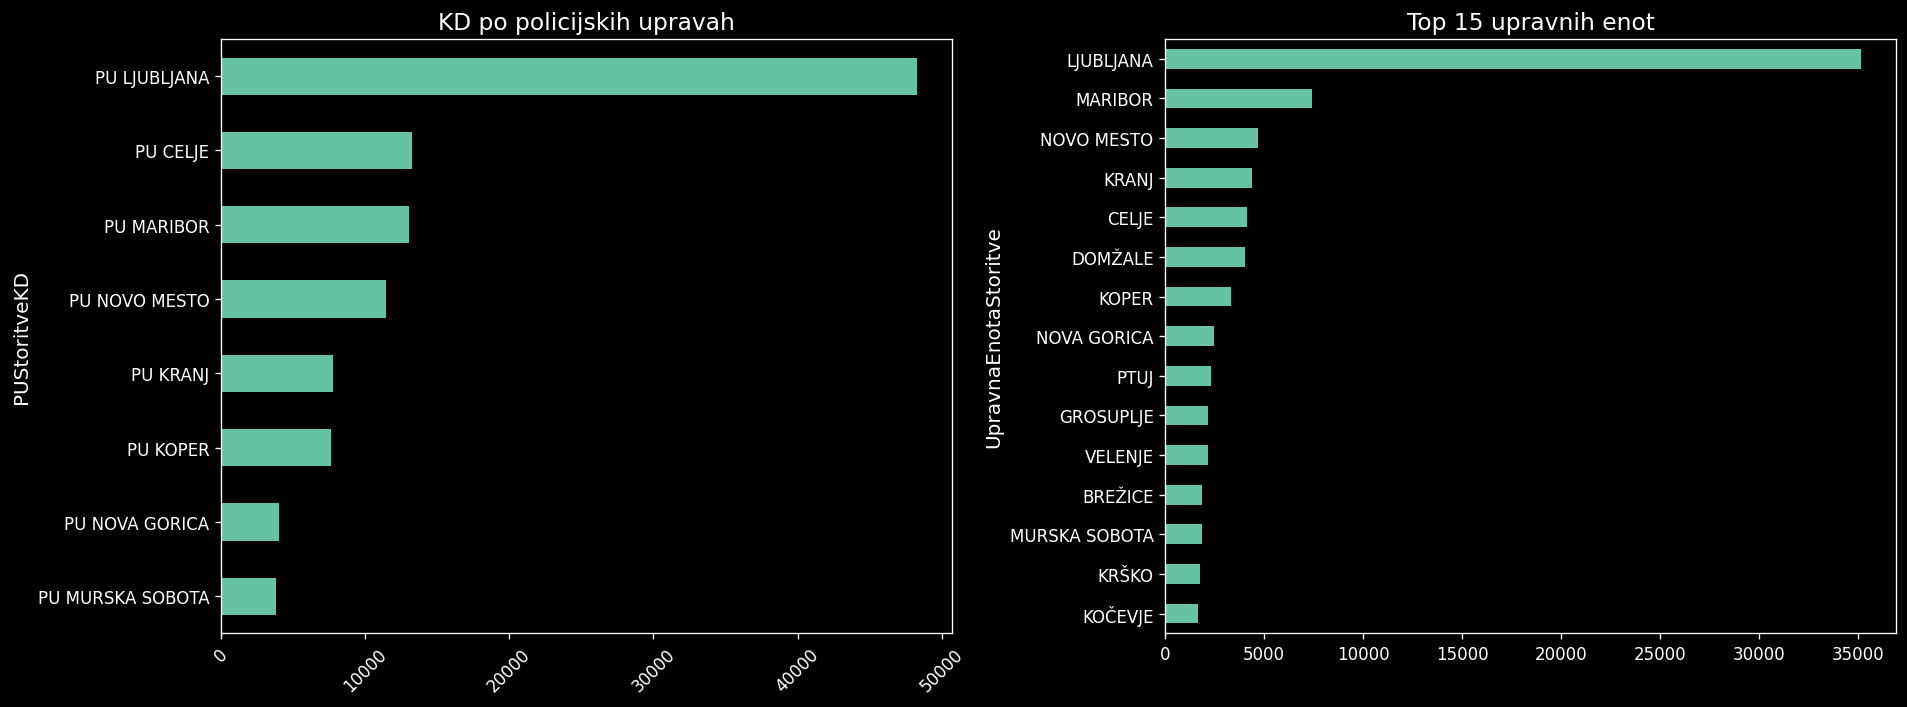

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pu_clean = df["PUStoritveKD"].dropna()
bar_plot(pu_clean, "KD po policijskih upravah", horizontal=True, ax=axes[0])

ue_clean = df["UpravnaEnotaStoritve"].dropna()
top_ue = ue_clean.value_counts().head(15)
top_ue.sort_values().plot.barh(ax=axes[1])
axes[1].set_title("Top 15 upravnih enot")
plt.tight_layout()
plt.show()

### 3.3 Kazniva dejanja na prebivalca


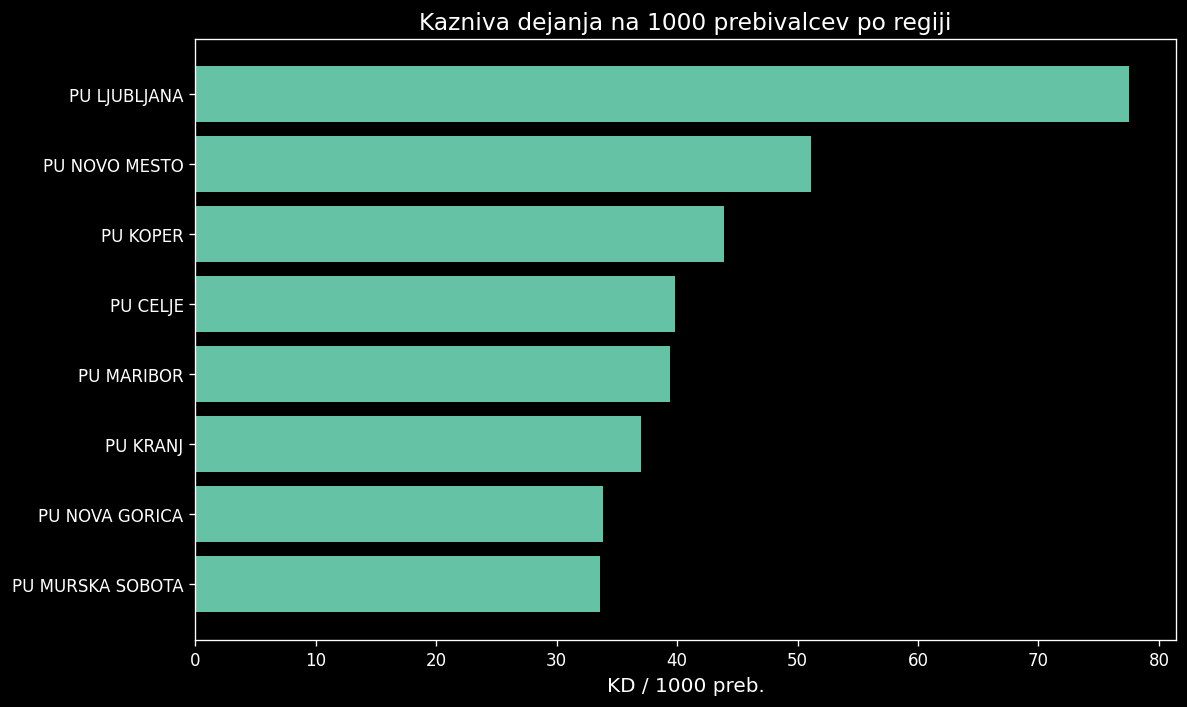

In [61]:
if "region" in pop.columns and "sum" in pop.columns:
    pu_counts = df["PUStoritveKD"].dropna().value_counts().reset_index()
    pu_counts.columns = ["region", "n_kd"]

    merged = pu_counts.merge(pop[["region", "sum"]], on="region", how="inner")
    merged["kd_per_1000"] = merged["n_kd"] / merged["sum"] * 1000
    merged = merged.sort_values("kd_per_1000", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(merged["region"], merged["kd_per_1000"])
    ax.set_title("Kazniva dejanja na 1000 prebivalcev po regiji")
    ax.set_xlabel("KD / 1000 preb.")
    plt.tight_layout()
    plt.show()
else:
    print("Populacijski podatki niso v pričakovanem formatu.")

### 3.4 Žrtev / osumljenec


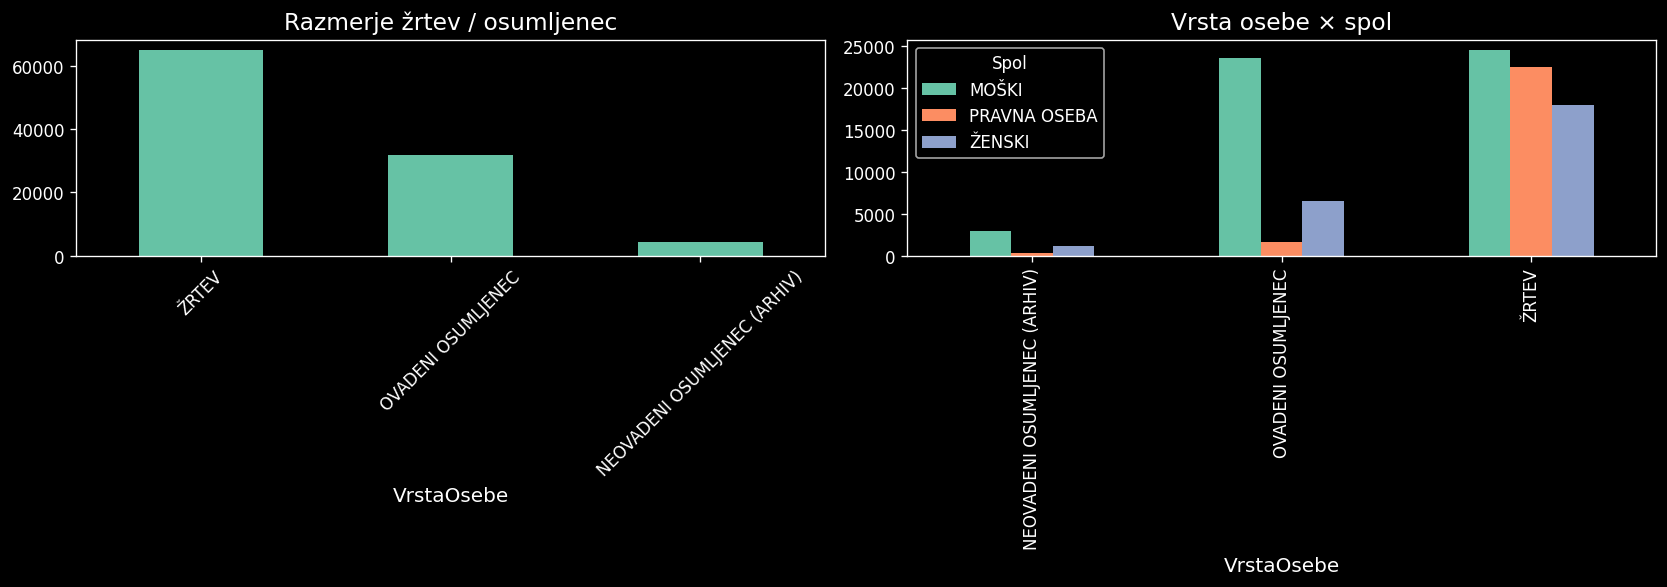

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_plot(df["VrstaOsebe"], "Razmerje žrtev / osumljenec", ax=axes[0])

ct = pd.crosstab(df["VrstaOsebe"], df["Spol"])
ct.plot.bar(ax=axes[1])
axes[1].set_title("Vrsta osebe × spol")
plt.tight_layout()
plt.show()

### 3.5 Državljanstvo


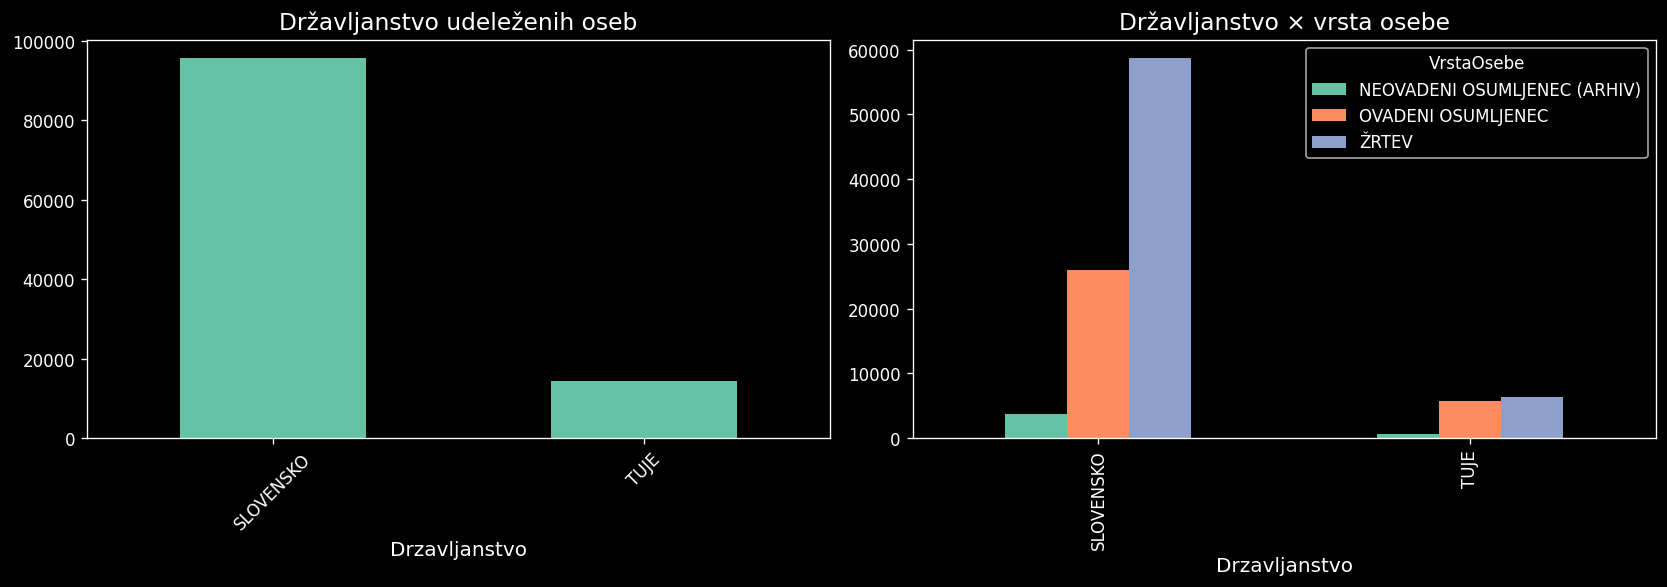

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_plot(df["Drzavljanstvo"], "Državljanstvo udeleženih oseb", ax=axes[0])

ct_drz = pd.crosstab(df["Drzavljanstvo"], df["VrstaOsebe"])
ct_drz.plot.bar(ax=axes[1])
axes[1].set_title("Državljanstvo × vrsta osebe")
plt.tight_layout()
plt.show()

### 3.6 Starostni razredi


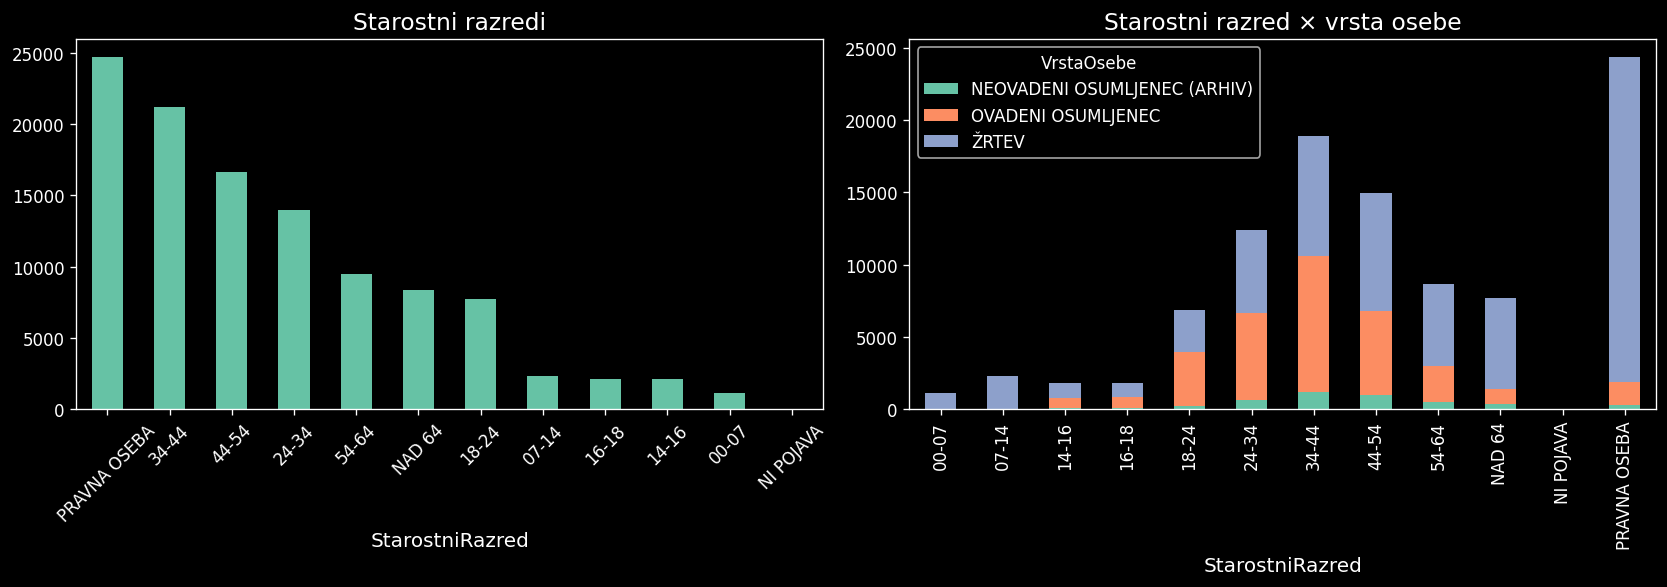

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_plot(df["StarostniRazred"], "Starostni razredi", ax=axes[0])

ct_star = pd.crosstab(df["StarostniRazred"], df["VrstaOsebe"])
ct_star.plot.bar(stacked=True, ax=axes[1])
axes[1].set_title("Starostni razred × vrsta osebe")
plt.tight_layout()
plt.show()

### 3.7 Uporabljena sredstva


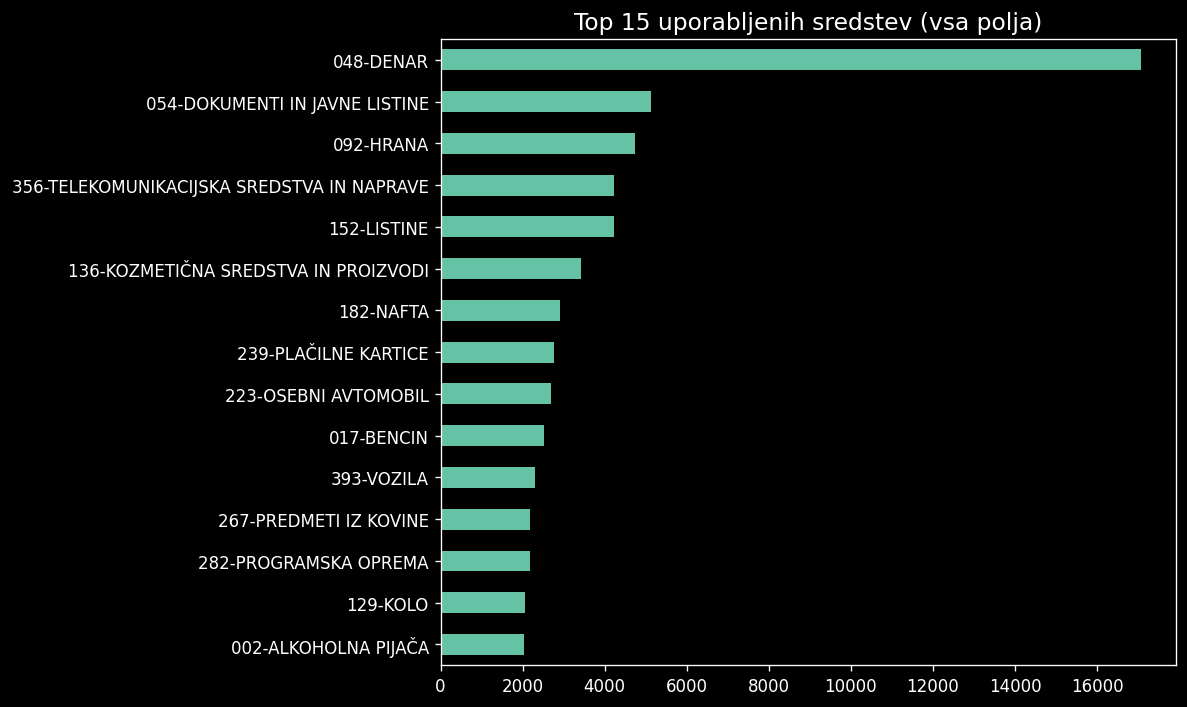

In [65]:
sredstva_cols = [
    "UporabljenoSredstvo1",
    "UporabljenoSredstvo2",
    "UporabljenoSredstvo3",
    "UporabljenoSredstvo4",
]
all_sredstva = pd.concat([df[c].dropna() for c in sredstva_cols if c in df.columns])
all_sredstva = all_sredstva[all_sredstva.str.strip() != ""]

fig, ax = plt.subplots(figsize=(10, 6))
top_s = all_sredstva.value_counts().head(15)
top_s.sort_values().plot.barh(ax=ax)
ax.set_title("Top 15 uporabljenih sredstev (vsa polja)")
plt.tight_layout()
plt.show()

### 3.8 Materialna škoda


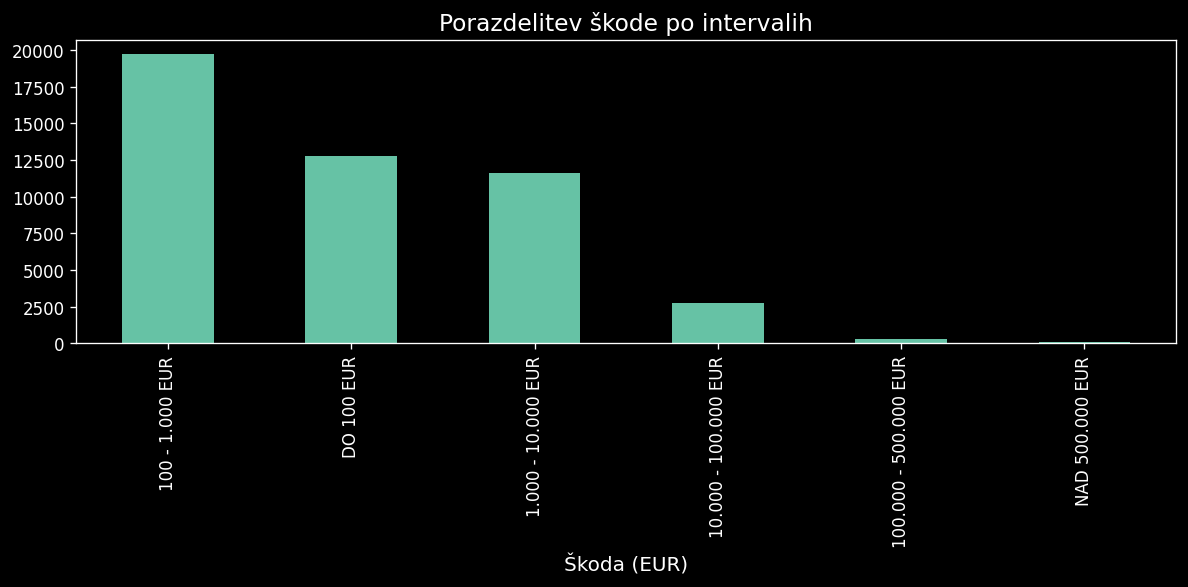

In [73]:
import re

skoda_counts = df["Skoda"].dropna()
skoda_counts = skoda_counts[skoda_counts != "0"]


def parse_skoda(x):
    digits = re.sub(r"[^\d]", "", x.split("-")[0])
    return int(digits) if digits else 0


skoda_order = sorted(skoda_counts.unique(), key=parse_skoda)

skoda_cat = pd.Categorical(skoda_counts, categories=skoda_order, ordered=True)
pd.Series(skoda_cat).value_counts().sort_index().plot.bar(figsize=(10, 5))
plt.title("Porazdelitev škode po intervalih")
plt.xlabel("Škoda (EUR)")
plt.tight_layout()
plt.show()

### 3.9 Alkohol, mamila, dokončanost


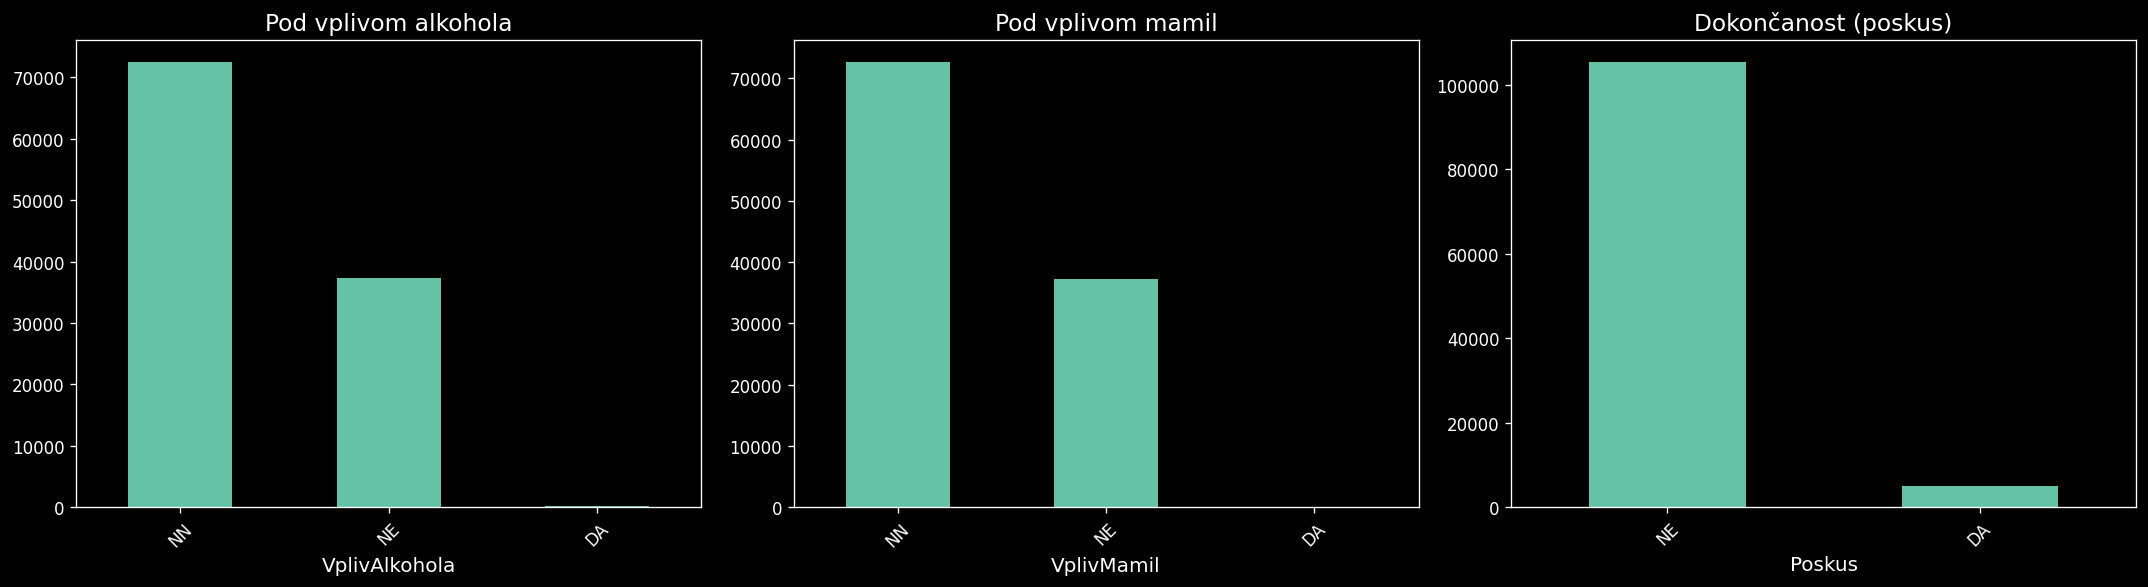

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_plot(df["VplivAlkohola"], "Pod vplivom alkohola", ax=axes[0])
bar_plot(df["VplivMamil"], "Pod vplivom mamil", ax=axes[1])
bar_plot(df["Poskus"], "Dokončanost (poskus)", ax=axes[2])
plt.tight_layout()
plt.show()

### 3.10 Top kazniva dejanja


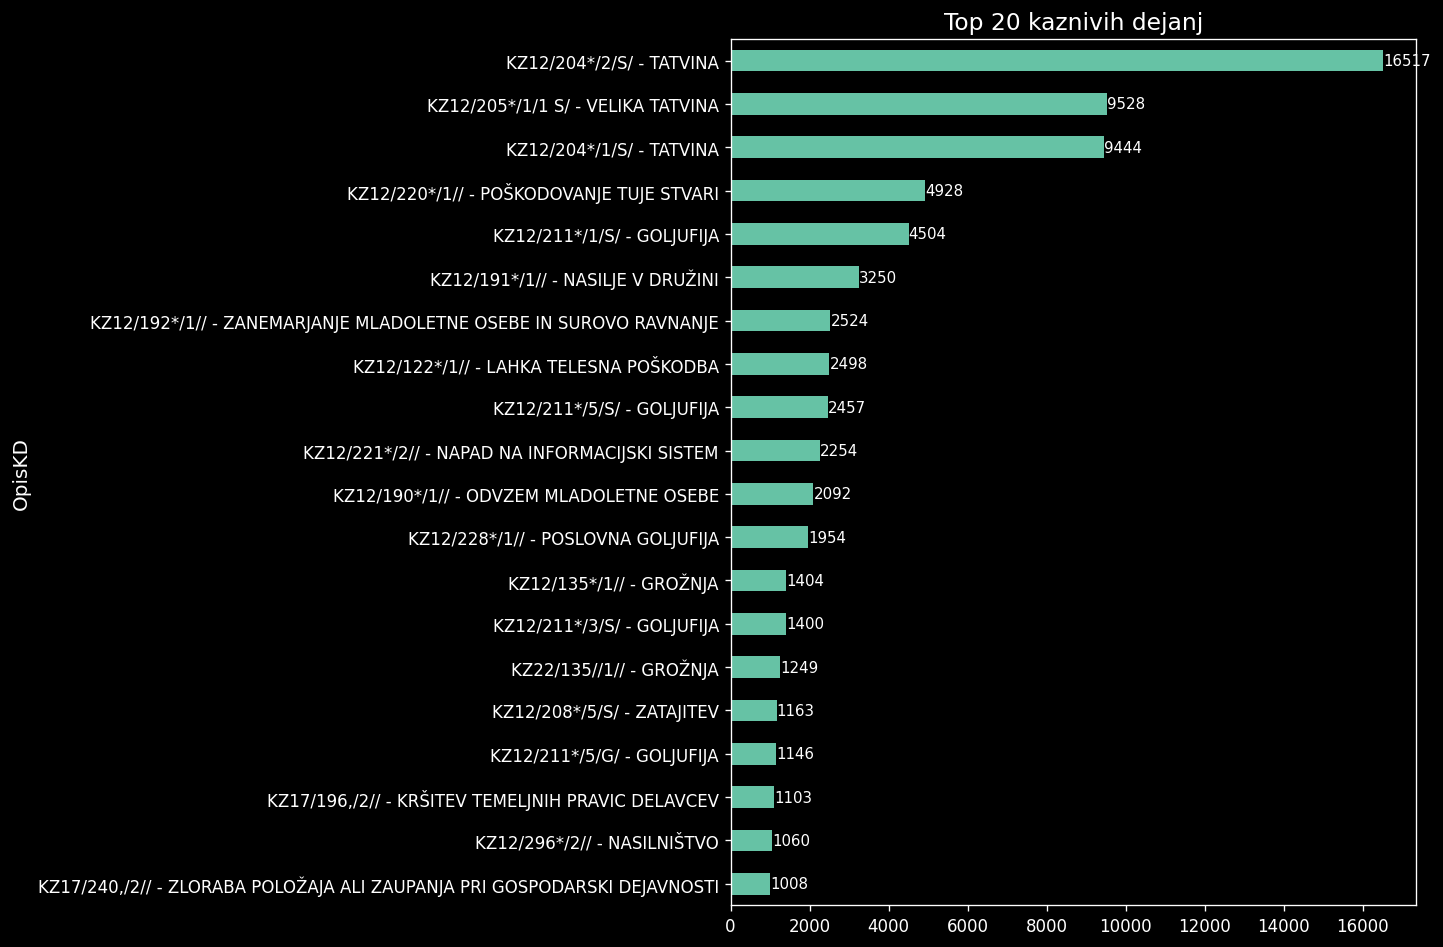

In [75]:
fig, ax = plt.subplots(figsize=(12, 8))
top_kd = df["OpisKD"].value_counts().head(20)
top_kd.sort_values().plot.barh(ax=ax)
ax.set_title("Top 20 kaznivih dejanj")
for i, (v, label) in enumerate(zip(top_kd.sort_values(), top_kd.sort_values().index)):
    ax.text(v + 5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

### 3.11 Prizorišče kaznivega dejanja


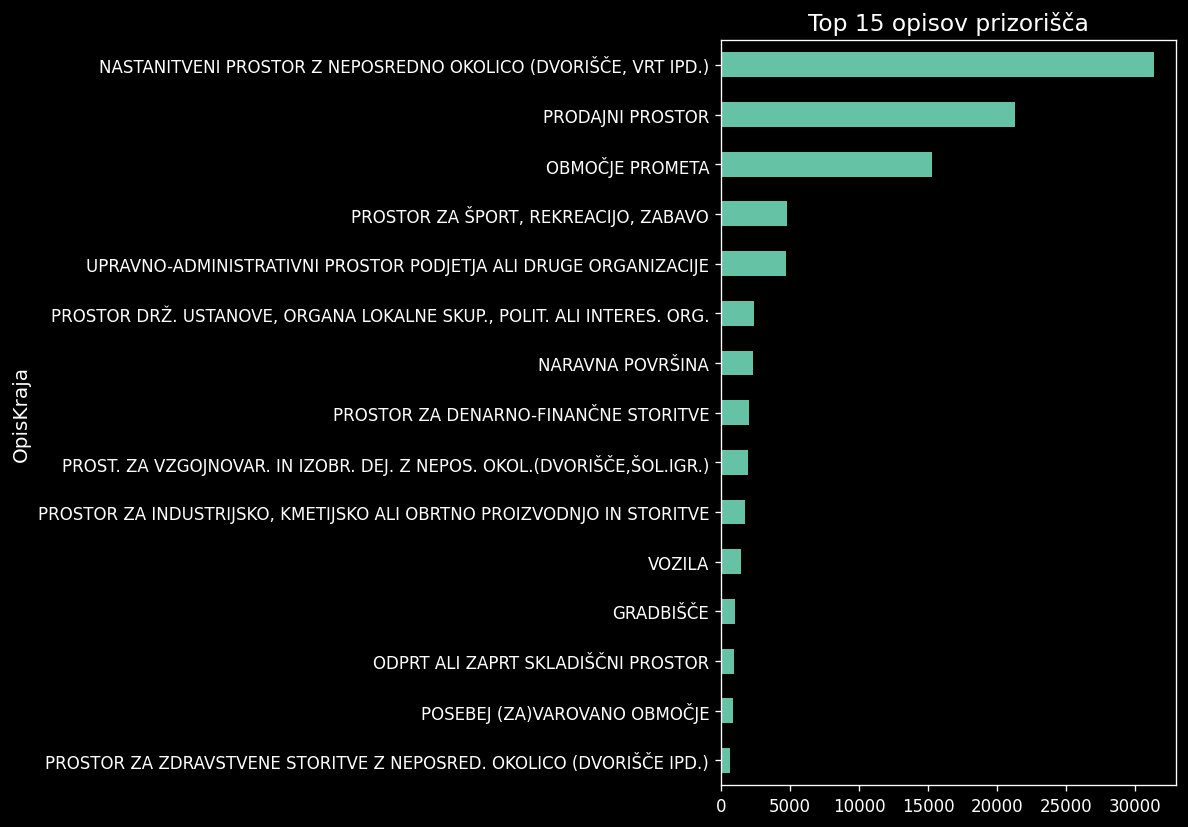

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))
top_kraj = df["OpisKraja"].value_counts().head(15)
top_kraj.sort_values().plot.barh(ax=ax)
ax.set_title("Top 15 opisov prizorišča")
plt.tight_layout()
plt.show()

## 4 Detekcija osamelcev

Osamelce identificiramo z variančno metodo (μ ± 2σ), Z-score, IQR in KS testom prilagajanja porazdelitve.


### 4.1 Variančna metoda — KD po upravnih enotah


In [76]:
ue_counts = df["UpravnaEnotaStoritve"].dropna().value_counts()
mean_ue = ue_counts.mean()
std_ue = ue_counts.std()
threshold = mean_ue + 2 * std_ue

outlier_ue = ue_counts[ue_counts > float(threshold)]
print(f"Prag: μ + 2σ = {threshold:.0f}")
print(f"\nUpravne enote z več KD od praga:")
display(outlier_ue.to_frame("n_KD"))

Prag: μ + 2σ = 10984

Upravne enote z več KD od praga:


,n_KD
UpravnaEnotaStoritve,
LJUBLJANA,35174


### 4.2 Z-score osamelci — materialna škoda


In [84]:
skoda_valid = pd.DataFrame()
outliers_skoda = pd.DataFrame()


def skoda_to_num(x):
    if pd.isna(x) or x == "0":
        return np.nan
    nums = re.findall(r"\d+", x.replace(".", ""))
    return int(nums[0]) if nums else np.nan


df["Skoda_num"] = df["Skoda"].apply(skoda_to_num)

if "Skoda_num" in df.columns:
    skoda_valid = df[["ZaporednaStevilkaKD", "OpisKD", "Skoda_num"]].dropna(subset=["Skoda_num"])
    skoda_valid = skoda_valid[skoda_valid["Skoda_num"] > 0].copy()
    skoda_valid.loc[:, "z_skoda"] = stats.zscore(np.log1p(skoda_valid["Skoda_num"]))

    outliers_skoda = skoda_valid[skoda_valid["z_skoda"].abs() > 3]
    print(f"Osamelci po škodi (|z| > 3 na log-skali): {len(outliers_skoda)}")
    display(outliers_skoda.nlargest(10, "Skoda_num")[["ZaporednaStevilkaKD", "OpisKD", "Skoda_num", "z_skoda"]])


Osamelci po škodi (|z| > 3 na log-skali): 416


,ZaporednaStevilkaKD,OpisKD,Skoda_num,z_skoda
13,9,KZ12/135*/1// - GROŽNJA,500000.0,5.141972
21,13,KZ12/228*/2// - POSLOVNA GOLJUFIJA,500000.0,5.141972
48,24,KZ12/253*/2/G/ - OVERITEV LAŽNE VSEBINE,500000.0,5.141972
59,27,KZ12/253*/2/G/ - OVERITEV LAŽNE VSEBINE,500000.0,5.141972
74,31,KZ12/229*/4// - GOLJUFIJA NA ŠKODO EVROPSKE UNIJE,500000.0,5.141972
138,48,KZ12/240*/2// - ZLORABA POLOŽAJA ALI ZAUPANJA ...,500000.0,5.141972
195,66,KZ12/209*/1// - PONEVERBA IN NEUPRAVIČENA UPOR...,500000.0,5.141972
209,72,KZ12/211*/1/S/ - GOLJUFIJA,500000.0,5.141972
217,75,KZ12/240*/2// - ZLORABA POLOŽAJA ALI ZAUPANJA ...,500000.0,5.141972
224,76,KZ08/227-/1// - OŠKODOVANJE UPNIKOV,500000.0,5.141972


### 4.3 IQR metoda — škoda


In [85]:
iqr_outliers = pd.DataFrame()

if not skoda_valid.empty:
    q1 = skoda_valid["Skoda_num"].quantile(0.25)
    q3 = skoda_valid["Skoda_num"].quantile(0.75)
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr

    iqr_outliers = skoda_valid[skoda_valid["Skoda_num"] > upper_fence]
    print(f"Q1 = {q1:,.0f}, Q3 = {q3:,.0f}, IQR = {iqr:,.0f}")
    print(f"Zgornja meja: {upper_fence:,.0f} EUR")
    print(f"Število osamelcev: {len(iqr_outliers)}")

Q1 = 100, Q3 = 1,000, IQR = 900
Zgornja meja: 2,350 EUR
Število osamelcev: 3155


### 4.4 KS test — prilagajanje porazdelitve škode


In [86]:
if not skoda_valid.empty:
    log_skoda = np.log1p(skoda_valid["Skoda_num"])
    ks_stat, ks_p = stats.kstest((log_skoda - log_skoda.mean()) / log_skoda.std(), "norm")
    print(f"KS test (log-škoda ~ normalna): stat = {ks_stat:.4f}, p = {ks_p:.4e}")
    if ks_p < 0.05:
        print("→ Zavrnemo H0: log-škoda ni normalno porazdeljena")
    else:
        print("→ Ne zavrnemo H0: log-škoda je približno normalna")

KS test (log-škoda ~ normalna): stat = 0.4144, p = 0.0000e+00
→ Zavrnemo H0: log-škoda ni normalno porazdeljena


### 4.5 Boxploti škode


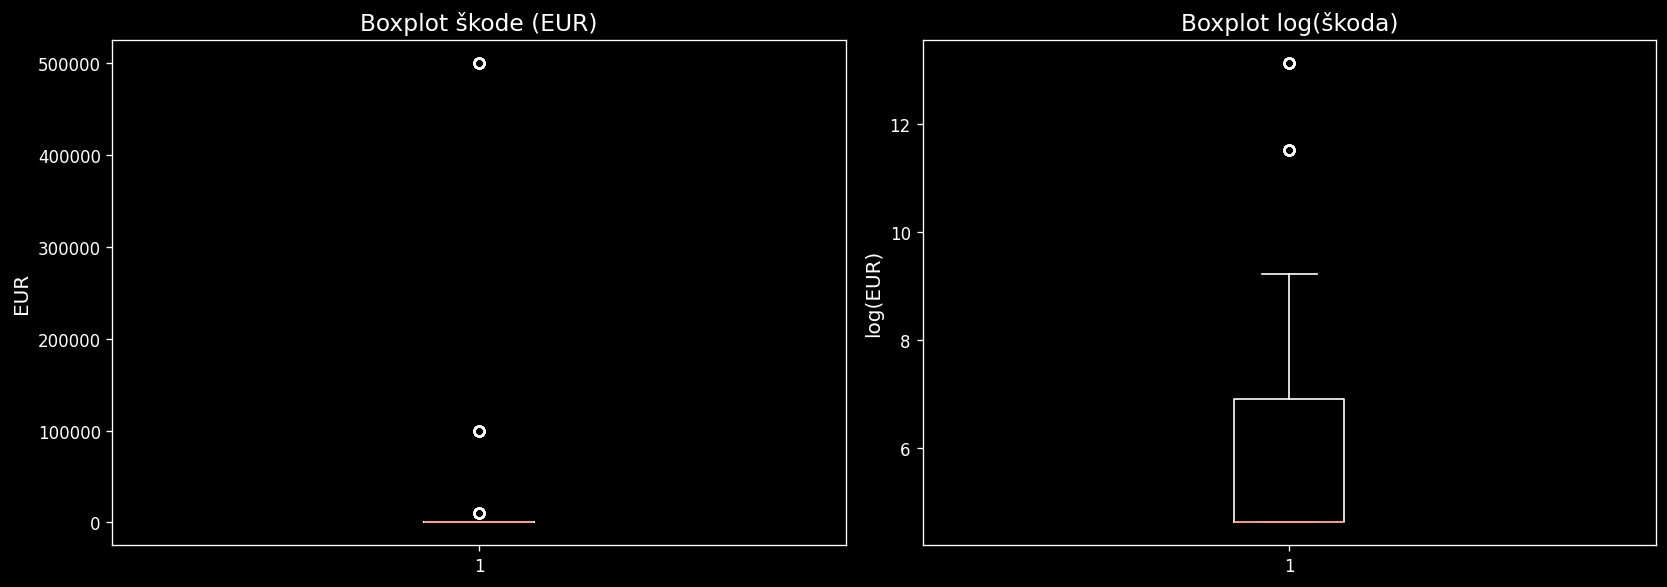

In [87]:
if not skoda_valid.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].boxplot(skoda_valid["Skoda_num"], vert=True)
    axes[0].set_title("Boxplot škode (EUR)")
    axes[0].set_ylabel("EUR")

    axes[1].boxplot(np.log1p(skoda_valid["Skoda_num"]), vert=True)
    axes[1].set_title("Boxplot log(škoda)")
    axes[1].set_ylabel("log(EUR)")
    plt.tight_layout()
    plt.show()

### 4.6 Časovni vzorci


In [88]:
hour_counts = df["UraStoritve"].value_counts(normalize=True).mul(100).round(1)
print("Porazdelitev KD po urah (%):")
print(hour_counts.sort_index().to_string())

Porazdelitev KD po urah (%):
UraStoritve
00:00-00:59    14.7
01:00-01:59     1.3
02:00-02:59     1.1
03:00-03:59     1.0
04:00-04:59     0.9
05:00-05:59     1.0
06:00-06:59     1.9
07:00-07:59     3.2
08:00-08:59     3.8
09:00-09:59     3.4
10:00-10:59     4.6
11:00-11:59     4.2
12:00-12:59     5.6
13:00-13:59     4.2
14:00-14:59     4.8
15:00-15:59     5.7
16:00-16:59     4.9
17:00-17:59     5.1
18:00-18:59     5.2
19:00-19:59     5.1
20:00-20:59     4.3
21:00-21:59     2.9
22:00-22:59     2.4
23:00-23:59     9.0


## 5 Gručenje

Upravne enote opišemo z agregiranimi značilkami (število KD, delež tujcev, alkohola, mamil, poskusov, gospodarski kriminal, povprečna in mediana škode).  
Uporabimo standardizacijo + PCA ter primerjamo K-Means in aglomerativno gručenje.


### 5.1 Priprava značilk


In [89]:
# za gručenje uporabimo samo vrstice z znano upravno enoto
df_cluster = df.dropna(subset=["UpravnaEnotaStoritve"]).copy()

ue_feat = (
    df_cluster.groupby("UpravnaEnotaStoritve")
    .agg(
        n_kd=("ZaporednaStevilkaKD", "nunique"),
        n_oseb=("ZaporednaStevilkaOsebeVKD", "nunique"),
        delez_tuje=("Drzavljanstvo", lambda x: (x == "TUJE").mean()),
        delez_alkohol=("VplivAlkohola", lambda x: x.dropna().eq("DA").mean() if x.notna().any() else np.nan),
        delez_mamil=("VplivMamil", lambda x: x.dropna().eq("DA").mean() if x.notna().any() else np.nan),
        delez_poskus=("Poskus", lambda x: x.dropna().eq("DA").mean() if x.notna().any() else np.nan),
        delez_gosp=("GospodarskiKriminal", lambda x: x.dropna().eq("DA").mean() if x.notna().any() else np.nan),
        povp_skoda=("Skoda_num", "mean"),
        med_skoda=("Skoda_num", "median"),
    )
    .reset_index()
)

# dodaj populacijo
if "region" in pop.columns:
    ue_feat = ue_feat.merge(
        pop[["region", "sum"]].rename(columns={"region": "UpravnaEnotaStoritve", "sum": "populacija"}),
        on="UpravnaEnotaStoritve",
        how="left",
    )
    if "populacija" in ue_feat.columns:
        ue_feat["kd_per_1000"] = ue_feat["n_kd"] / ue_feat["populacija"] * 1000

# odstrani enote s premalo podatkov (> 50 % NaN značilk)
feat_only = [c for c in ue_feat.columns if c not in ("UpravnaEnotaStoritve", "populacija")]
nan_ratio = ue_feat[feat_only].isna().mean(axis=1)
ue_feat = ue_feat[nan_ratio <= 0.5].reset_index(drop=True)

print(f"Dimenzij: {len(feat_only)}, Upravnih enot (po filtriranju): {len(ue_feat)}")
display(ue_feat.head(10))

Dimenzij: 10, Upravnih enot (po filtriranju): 60


,UpravnaEnotaStoritve,n_kd,n_oseb,delez_tuje,delez_alkohol,delez_mamil,delez_poskus,delez_gosp,povp_skoda,med_skoda,populacija,kd_per_1000
0,AJDOVŠČINA,390,642,0.140187,0.006231,0.000000,0.076324,0.0,4521.543408,100.0,NaN,NaN
1,BREŽICE,1094,1838,0.180354,0.001088,0.000000,0.070853,0.0,2227.394958,100.0,NaN,NaN
2,CELJE,2353,4127,0.119094,0.000727,0.000727,0.035198,0.0,4011.626575,100.0,NaN,NaN
3,CERKNICA,207,407,0.120098,0.004914,0.000000,0.058824,0.0,3534.042553,100.0,NaN,NaN
4,DOMŽALE,2354,4018,0.089485,0.001244,0.000000,0.041263,0.0,2929.657228,100.0,NaN,NaN
5,DRAVOGRAD,108,196,0.106061,0.000000,0.000000,0.050505,0.0,950.000000,100.0,NaN,NaN
6,GORNJA RADGONA,354,647,0.114855,0.001546,0.000000,0.026034,0.0,5187.000000,100.0,NaN,NaN
7,GROSUPLJE,1272,2162,0.106138,0.001388,0.000463,0.076142,0.0,2226.325758,100.0,NaN,NaN
8,HRASTNIK,122,201,0.059406,0.000000,0.000000,0.059406,0.0,467.105263,100.0,NaN,NaN
9,IDRIJA,249,440,0.142534,0.002273,0.002273,0.052036,0.0,2211.764706,100.0,NaN,NaN


### 5.2 Standardizacija + PCA


In [90]:
feature_cols = [c for c in ue_feat.columns if c not in ("UpravnaEnotaStoritve", "populacija")]

X = ue_feat[feature_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Pojasnjena varianca:  {pca.explained_variance_ratio_.sum():.2%}")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.2%}")

Pojasnjena varianca:  45.89%
  PC1: 25.49%
  PC2: 20.40%


### 5.3 Optimalno število gruč


  K=2: silhouette = 0.7010
  K=3: silhouette = 0.3561
  K=4: silhouette = 0.3739
  K=5: silhouette = 0.3022
  K=6: silhouette = 0.2076
  K=7: silhouette = 0.2306
  K=8: silhouette = 0.1758
  K=9: silhouette = 0.2196
  K=10: silhouette = 0.2026

→ Optimalno K = 2 (silhouette = 0.7010)


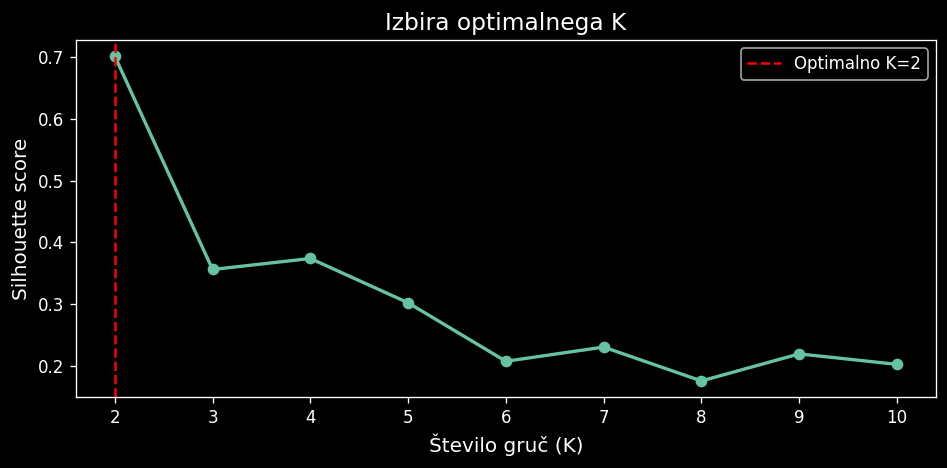

In [91]:
K_range = range(2, min(11, len(ue_feat)))
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)
    print(f"  K={k}: silhouette = {sil:.4f}")

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"\n→ Optimalno K = {best_k} (silhouette = {max(silhouettes):.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), silhouettes, "o-", linewidth=2)
ax.axvline(best_k, color="red", linestyle="--", label=f"Optimalno K={best_k}")
ax.set_xlabel("Število gruč (K)")
ax.set_ylabel("Silhouette score")
ax.set_title("Izbira optimalnega K")
ax.legend()
plt.tight_layout()
plt.show()

### 5.4 K-Means gručenje


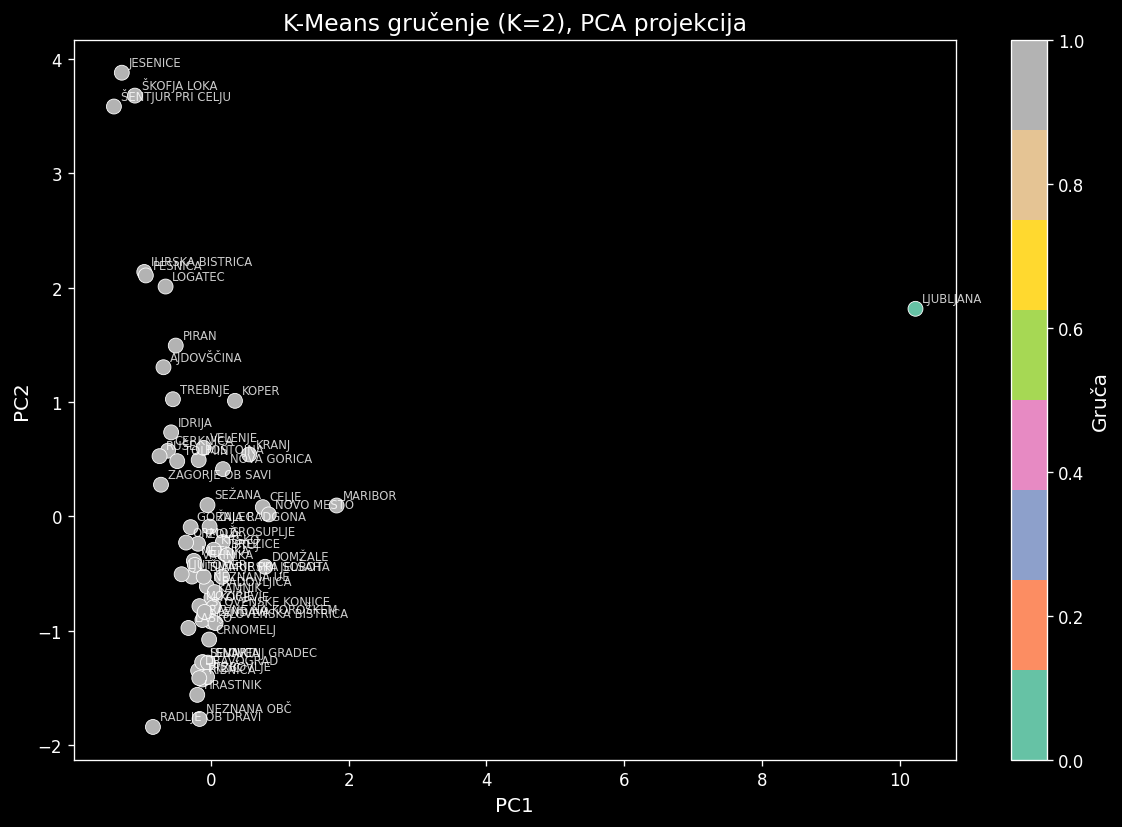

In [92]:
km_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
ue_feat["cluster_kmeans"] = km_final.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=ue_feat["cluster_kmeans"], cmap="Set2", s=80, edgecolors="white", linewidth=0.5)
for i, name in enumerate(ue_feat["UpravnaEnotaStoritve"]):
    ax.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=7, alpha=0.8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"K-Means gručenje (K={best_k}), PCA projekcija")
plt.colorbar(scatter, label="Gruča")
plt.tight_layout()
plt.show()

### 5.5 Aglomerativno gručenje


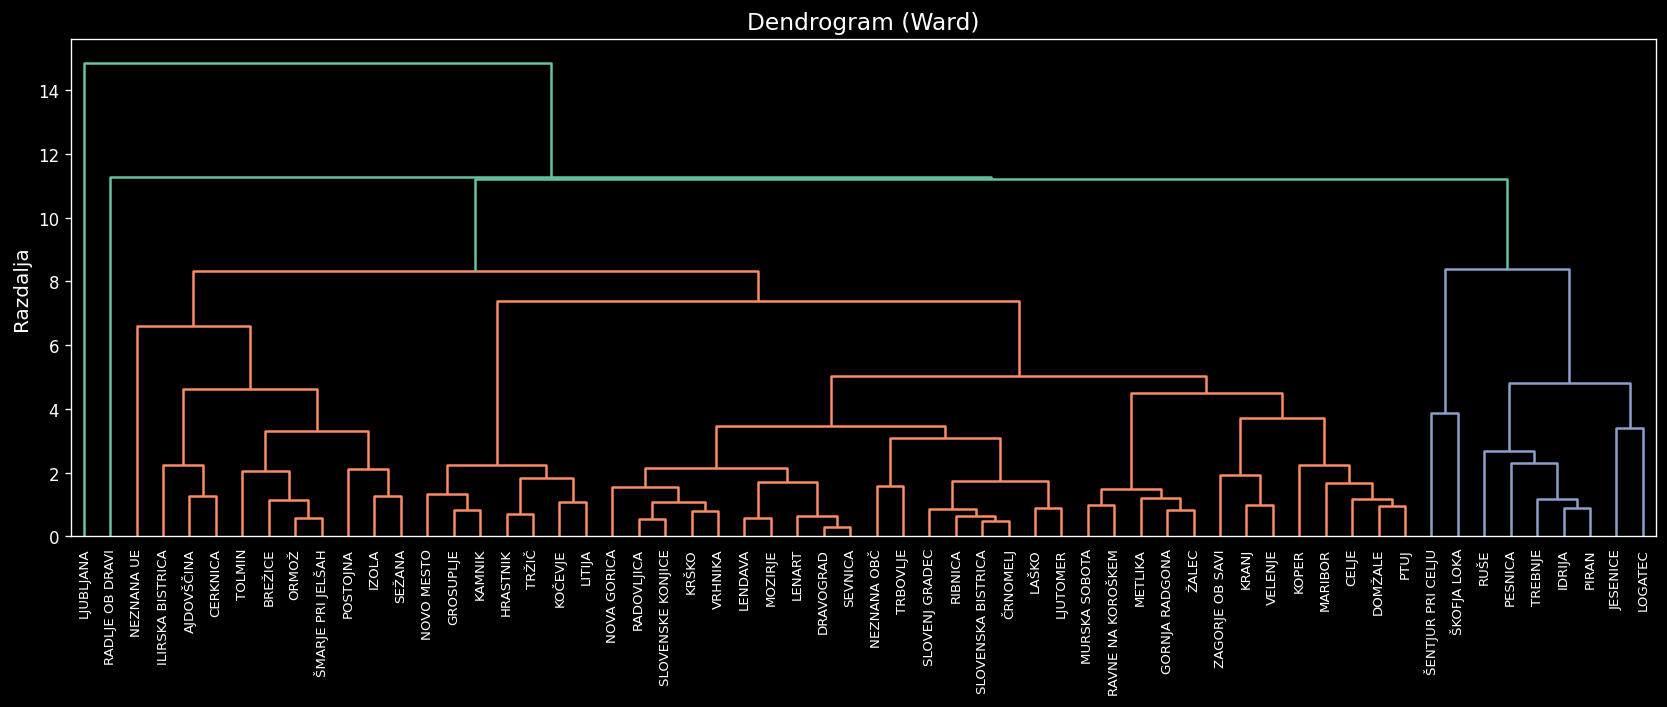

In [93]:
Z_linkage = linkage(X_scaled, method="ward")

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z_linkage, labels=ue_feat["UpravnaEnotaStoritve"].values, leaf_rotation=90, leaf_font_size=8, ax=ax)
ax.set_title("Dendrogram (Ward)")
ax.set_ylabel("Razdalja")
plt.tight_layout()
plt.show()

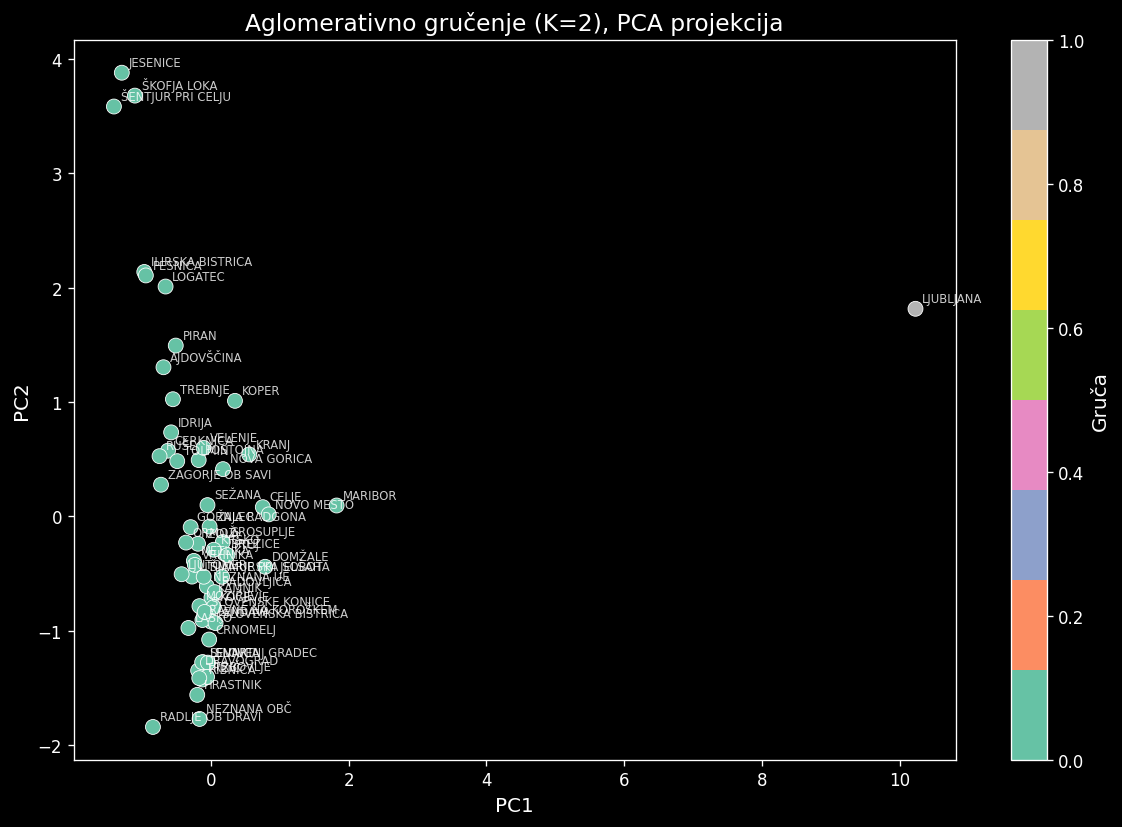

In [94]:
agg = AgglomerativeClustering(n_clusters=best_k)
ue_feat["cluster_agg"] = agg.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=ue_feat["cluster_agg"], cmap="Set2", s=80, edgecolors="white", linewidth=0.5)
for i, name in enumerate(ue_feat["UpravnaEnotaStoritve"]):
    ax.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=7, alpha=0.8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Aglomerativno gručenje (K={best_k}), PCA projekcija")
plt.colorbar(scatter, label="Gruča")
plt.tight_layout()
plt.show()

### 5.6 Profili gruč


In [34]:
print("Povprečne vrednosti značilk po gručah (K-Means):\n")
profil = ue_feat.groupby("cluster_kmeans")[feature_cols].mean()
display(profil.T.round(3))

Povprečne vrednosti značilk po gručah (K-Means):



cluster_kmeans,0,1
n_kd,21035.000,734.932
n_oseb,35063.000,1249.508
delez_tuje,0.161,0.121
delez_alkohol,0.001,0.002
delez_mamil,0.000,0.001
delez_poskus,0.046,0.047
delez_gosp,0.000,0.000
povp_skoda,0.000,0.000
med_skoda,0.000,0.000
kd_per_1000,NaN,NaN


### 5.7 Primerjava K-Means in aglomerativnega gručenja


In [95]:
ari = adjusted_rand_score(ue_feat["cluster_kmeans"], ue_feat["cluster_agg"])
print(f"Adjusted Rand Index: {ari:.4f}")

# cross tabela
ct_clusters = pd.crosstab(ue_feat["cluster_kmeans"], ue_feat["cluster_agg"], rownames=["K-Means"], colnames=["Aglomerativno"])
display(ct_clusters)

Adjusted Rand Index: 1.0000


Aglomerativno,0,1
K-Means,,
0,0,1
1,59,0


## 6 Povzetek


In [96]:
print(f"""
═══════════════════════════════════
  POVZETEK ANALIZE
═══════════════════════════════════

Podatki:    {len(df):,} vrstic, {df["ZaporednaStevilkaKD"].nunique():,} unikatnih KD
Leto:       {YEAR}
Regije:     {df["PUStoritveKD"].nunique()} policijskih uprav
Upravne e.: {df["UpravnaEnotaStoritve"].nunique()} upravnih enot

Gručenje:
  Optimalno K:       {best_k}
  Silhouette (KM):   {max(silhouettes):.4f}
  ARI (KM vs Agg):   {ari:.4f}

Osamelci (škoda):
  Z-score (|z|>3):   {len(outliers_skoda) if not outliers_skoda.empty else "N/A"}
  IQR osamelci:      {len(iqr_outliers) if not iqr_outliers.empty else "N/A"}
""")


═══════════════════════════════════
  POVZETEK ANALIZE
═══════════════════════════════════

Podatki:    110,452 vrstic, 65,297 unikatnih KD
Leto:       2024
Regije:     8 policijskih uprav
Upravne e.: 60 upravnih enot

Gručenje:
  Optimalno K:       2
  Silhouette (KM):   0.7010
  ARI (KM vs Agg):   1.0000

Osamelci (škoda):
  Z-score (|z|>3):   416
  IQR osamelci:      3155

